## This is the code for generating different loss groups' influence distribution plot.

By default, if you play this file directly, it will generate the high and low loss group influence score distribution plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists and Loss lists -> Merge the two lists to have both influence score and loss for each sample -> Split samples into 4 groups from highest to lowest based on their loss values -> Plot the influence score distribution of high and low loss groups

**Format**:  
**Input** The Influence lists that you read in.  
**Output**  The influence score distribution Plot for high and low loss groups.

You don't need to change anything else if you only want to produce the score distribution plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [55]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns
from scipy.stats import gaussian_kde

1. Read in the influence and loss lists here.

In [56]:
IF_1 = pd.read_csv("Outliers/IF_Train_Set_1.csv")
IF_2 = pd.read_csv("Outliers/IF_Train_Set_2.csv")
IF_3 = pd.read_csv("Outliers/IF_Train_Set_3.csv")
IF_4 = pd.read_csv("Outliers/IF_Train_Set_4.csv")
IF_5 = pd.read_csv("Outliers/IF_Train_Set_5.csv")

TC_1 = pd.read_csv("Outliers/TC_Train_Set_1.csv")
TC_2 = pd.read_csv("Outliers/TC_Train_Set_2.csv")
TC_3 = pd.read_csv("Outliers/TC_Train_Set_3.csv")
TC_4 = pd.read_csv("Outliers/TC_Train_Set_4.csv")
TC_5 = pd.read_csv("Outliers/TC_Train_Set_5.csv")

Loss_1 = pd.read_csv("Outliers/Train_Loss_Train_Set_1.csv")
Loss_2 = pd.read_csv("Outliers/Train_Loss_Train_Set_2.csv")
Loss_3 = pd.read_csv("Outliers/Train_Loss_Train_Set_3.csv")
Loss_4 = pd.read_csv("Outliers/Train_Loss_Train_Set_4.csv")
Loss_5 = pd.read_csv("Outliers/Train_Loss_Train_Set_5.csv")

In [57]:
IF_lists = [IF_1,IF_2,IF_3,IF_4,IF_5]
TC_lists = [TC_1,TC_2,TC_3,TC_4,TC_5]
Loss_lists = [Loss_1,Loss_2,Loss_3,Loss_4,Loss_5]

Influence Function Frequency, take IF1 and Loss1 as example. No abs suppose.

In [58]:
print(IF_1)
print(TC_1)
print(Loss_1)

     Train_ID     Score
0          33  0.146913
1         737  0.090702
2         752  0.083292
3         458  0.082790
4         214  0.081532
..        ...       ...
995       382 -0.547967
996       358 -0.572584
997       771 -0.586427
998       313 -0.643067
999       777 -0.767428

[1000 rows x 2 columns]
     Train_ID     Score
0           1  0.006673
1         358  0.003858
2         715  0.003383
3         833  0.003380
4         480  0.003111
..        ...       ...
995       962 -0.007583
996       179 -0.007628
997       313 -0.007658
998       771 -0.007882
999       777 -0.011250

[1000 rows x 2 columns]
     Train_ID      Loss
0           1  4.659351
1         382  4.075436
2         711  3.866180
3         777  3.399041
4         358  3.294481
..        ...       ...
995       880  0.000060
996       360  0.000053
997       717  0.000039
998       403  0.000035
999       385  0.000030

[1000 rows x 2 columns]


2. We merge the IF/TC influence list with the loss list.

In [59]:
df_1 = pd.merge(IF_1, Loss_1, on="Train_ID")
df_2 = pd.merge(IF_2, Loss_2, on="Train_ID")
df_3 = pd.merge(IF_3, Loss_3, on="Train_ID")
df_4 = pd.merge(IF_4, Loss_4, on="Train_ID")
df_5 = pd.merge(IF_5, Loss_5, on="Train_ID")

In [60]:
df_1["Score"] = df_1["Score"].abs()

3. Next we turn them into 4 percentile based on their loss. 

In [61]:
q = df_1["Loss"].quantile([0.25, 0.5, 0.75])
bins = [-float("inf"), q[0.25], q[0.5], q[0.75], float("inf")]
labels = ["Low", "MidLo", "MidHi", "High"] 

df_1["loss_quartile"] = pd.cut(df_1["Loss"], bins=bins, labels=labels, include_lowest=True, right=True)

Then we show the influence distribution of high and low loss group with their mean value shown as a verticle line there.

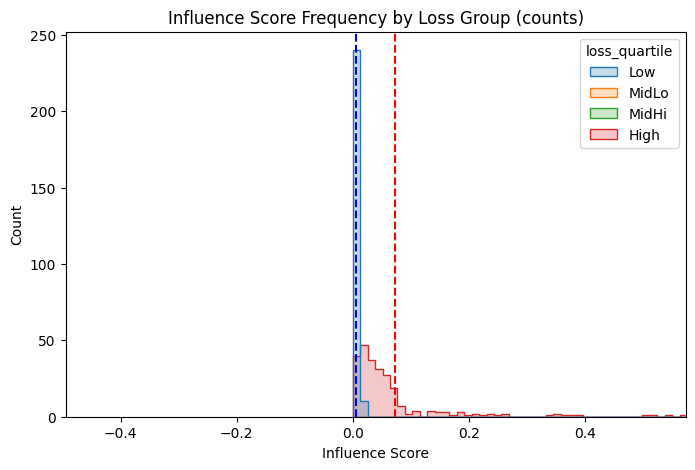

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df_1[df_1["loss_quartile"].isin(["Low","High"])],
    x="Score", hue="loss_quartile",
    element="step", stat="count", common_norm=False, bins=60
)

high_mean = df_1.loc[df_1["loss_quartile"] == "High", "Score"].mean()
plt.axvline(high_mean, color="red", linestyle="--", linewidth=1.5)

low_mean = df_1.loc[df_1["loss_quartile"] == "Low", "Score"].mean()
plt.axvline(low_mean, color="blue", linestyle="--", linewidth=1.5)

margin = 0.5
xmin = min(low_mean, high_mean) - margin
xmax = max(low_mean, high_mean) + margin
plt.xlim(xmin, xmax)

plt.xlabel("Influence Score")
plt.ylabel("Count")
plt.title("Influence Score Frequency by Loss Group (counts)")
plt.show()

How many highly influential points are lie in high loss/low loss groups can be checked here.

In [63]:
mean_loss = df_1["Loss"].mean()
df_1["loss_group"] = np.where(df_1["Loss"] > mean_loss, "High Loss", "Low Loss")

top_pct = 0.2
threshold = df_1["Score"].quantile(1 - top_pct)

df_1["is_top_influential"] = df_1["Score"] >= threshold

summary = df_1.groupby("loss_group")["is_top_influential"].mean() * 100

print(f"Top {int(top_pct*100)}% most influential points (by absolute score):")
print(summary)

Top 20% most influential points (by absolute score):
loss_group
High Loss    48.235294
Low Loss     10.335570
Name: is_top_influential, dtype: float64


It means: within high loss, 48% of the points are lied inside top 20% most influential. While in low loss, only 10% stays.

4. The following plots all the 5 runs at the same time. Currently, it generates the TracIn plot. If you want to generate the Influence Function plots, remember to change TC_1, TC_2, TC_3, TC_4 and TC_5 to IF_1, IF_2, IF_3, IF_4 and IF_5. The plot will also be saved in the root directory. Remember also to change the filename when changing from TC to IF.

In [64]:
df_1 = pd.merge(TC_1, Loss_1, on="Train_ID")
df_2 = pd.merge(TC_2, Loss_2, on="Train_ID")
df_3 = pd.merge(TC_3, Loss_3, on="Train_ID")
df_4 = pd.merge(TC_4, Loss_4, on="Train_ID")
df_5 = pd.merge(TC_5, Loss_5, on="Train_ID")

In [65]:
dfs = [df_1, df_2, df_3, df_4, df_5]

In [1]:
def plot_with_peaks(df, run_id):
    q = df["Loss"].quantile([0.25, 0.5, 0.75])
    bins = [-float("inf"), q[0.25], q[0.5], q[0.75], float("inf")]
    labels = ["Low", "Low-Mid", "High-Mid", "High"] 
    
    df["loss_quartile"] = pd.cut(df["Loss"], bins=bins, labels=labels, include_lowest=True, right=True)
    df["Score"] = df["Score"].abs()
    plt.figure(figsize=(8,5))
    sns.histplot(
        data=df[df["loss_quartile"].isin(["Low","High"])],
        x="Score", hue="loss_quartile",
        element="step", stat="count", common_norm=False, bins=60
    )
    
    mean_val = df.loc[df["loss_quartile"] == "High", "Score"].median()
    plt.axvline(mean_val, color="red", linestyle="--", linewidth=1.5)
    
    mean_val = df.loc[df["loss_quartile"] == "Low", "Score"].median()
    plt.axvline(mean_val, color="blue", linestyle="--", linewidth=1.5)
    
    plt.xlabel("Influence Score")
    plt.ylabel("Count")
    title = "Influence Score Frequency by Loss Group (counts) - Run " + str(run_id)
    plt.title(title)  
    plt.xlim(0, 0.004)  # 0.004 for TC and 0.4 for IF
    plt.savefig(f"run_{run_id}_sens_TC.png")
    plt.show()
    plt.close()


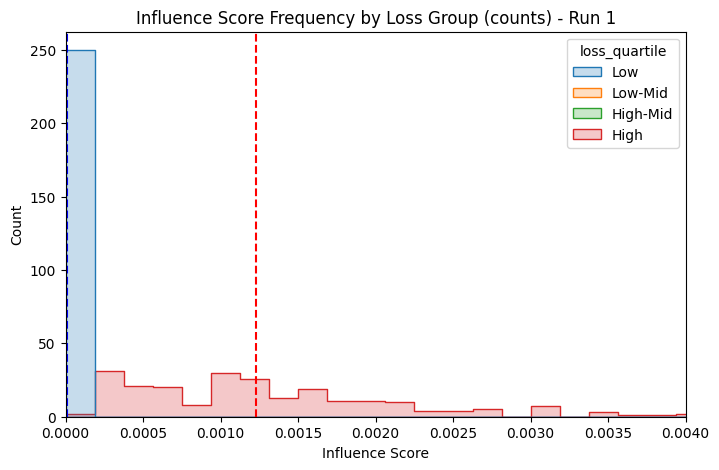

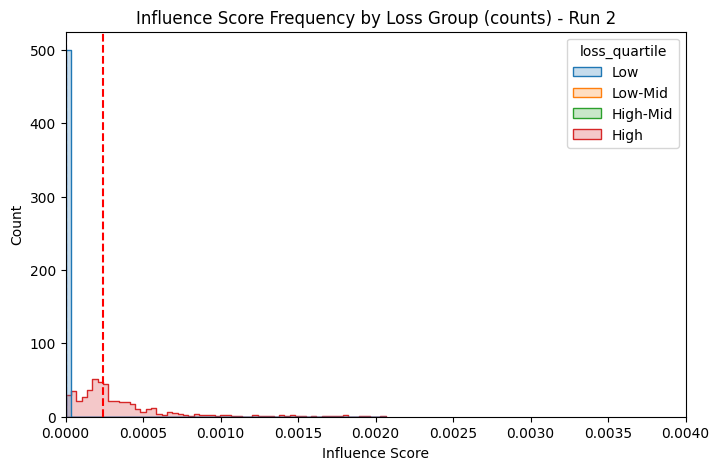

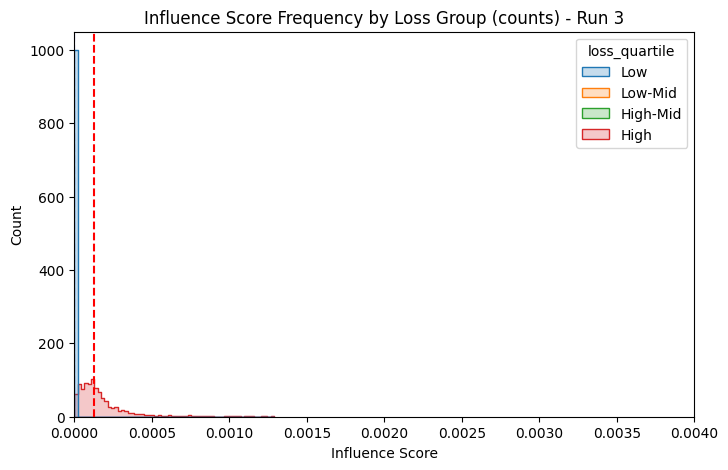

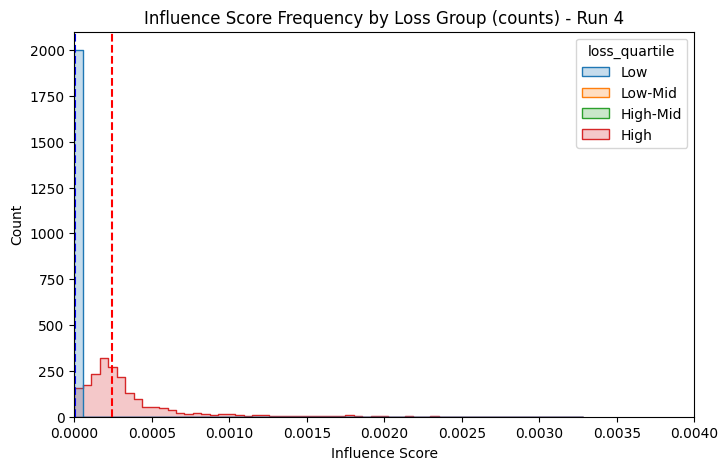

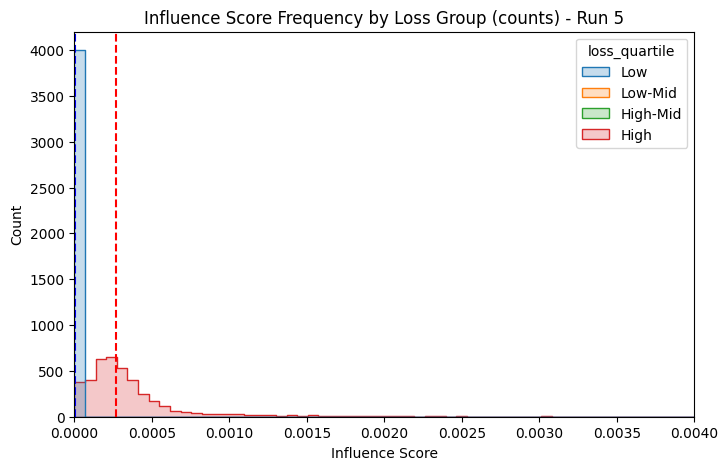

In [67]:
for i, df in enumerate(dfs, start=1):
    plot_with_peaks(df, i)